Exploratory Data Analysis playbook part
In this part we are going to exploriate our data set to understand its structure, data types and identify patterns
we start by importing libraries we are going to use:
- pandas
- matplotlib
- seaborn
- numpy

 step 1: Environmental setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)
%matplotlib inline

step 2: load data

In [3]:
df = pd.read_csv("cleaned_2024_digital_products_expenditure_dataset.csv")

Step 3: The First look and data audit
We check the "skeleton" of the data. We are looking for data type mismatches (e.g., a price column showing up as an object/string).

In [5]:
df.info()

# checking for missing values as percentage
null_report = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\n--- Missing values expressed in percentage ---")
print(null_report[null_report>0])

# checking on duplicated values
print(f"\Duplicate Rows: {df.duplicated().sum()}")

# checking for null values
print("\n--- Unique values per column ---")
print(df.nunique())

print("\n--- Shape of the dataset ---")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6820 entries, 0 to 6819
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0.1                       6820 non-null   int64  
 1   Unnamed: 0                         6820 non-null   int64  
 2   newid                              6820 non-null   int64  
 3   seqno                              6820 non-null   int64  
 4   expname                            6820 non-null   object 
 5   cost_flag                          6820 non-null   object 
 6   ref_mo                             6820 non-null   object 
 7   ref_yr                             6820 non-null   int64  
 8   gift                               6820 non-null   bool   
 9   cost                               6820 non-null   int64  
 10  fam_size                           6820 non-null   int64  
 11  family_income_before_tax           6820 non-null   int64

continuation of the data audit step, lets check the statistical summary of our dataset

In [6]:
print("\n--- Statistical summary ---")
print(df.describe())


--- Statistical summary ---
       Unnamed: 0.1    Unnamed: 0         newid        seqno  ref_yr  \
count    6820.00000   6820.000000  6.820000e+03  6820.000000  6820.0   
mean     3409.50000   7599.156012  5.492532e+06    28.272874  2024.0   
std      1968.90875   4360.542943  9.574756e+04    15.837898     0.0   
min         0.00000      0.000000  5.343904e+06     1.000000  2024.0   
25%      1704.75000   3774.750000  5.426493e+06    17.000000  2024.0   
50%      3409.50000   7756.000000  5.551652e+06    26.000000  2024.0   
75%      5114.25000  11433.250000  5.586774e+06    36.000000  2024.0   
max      6819.00000  14911.000000  5.607981e+06   120.000000  2024.0   

              cost     fam_size  family_income_before_tax  calibration_weight  \
count  6820.000000  6820.000000               6820.000000         6820.000000   
mean     91.713930     2.423460             126679.242229        24417.613587   
std     173.112013     1.359494             132673.390761        11769.372724  

Step 3: Univariate Analysis
We analyze one variable at a time to identify skewness and any possible outliers.

1. Numerical variables.

['Unnamed: 0.1', 'Unnamed: 0', 'newid', 'seqno', 'ref_yr', 'cost', 'fam_size', 'family_income_before_tax', 'calibration_weight', 'number_of_earners', 'interview_year', 'total_expenditure_prior_quarter', 'total_expenditure_current_quarter', 'imputed_income_before_tax']


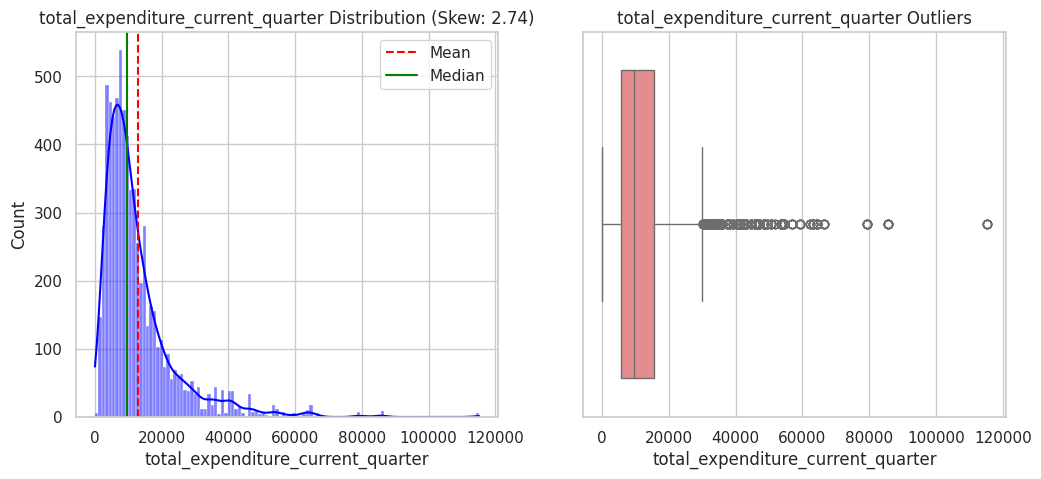

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(num_cols)

col = "total_expenditure_current_quarter"

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df[col],kde=True,color='blue')
plt.axvline(df[col].mean(), color = 'red', linestyle='--',label='Mean')
plt.axvline(df[col].median(),color ='green',linestyle='-', label='Median')
plt.title(f'{col} Distribution (Skew: {df[col].skew():.2f})')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x=df[col],color='lightcoral')
plt.title(f'{col} Outliers')
plt.show()
plt.show()

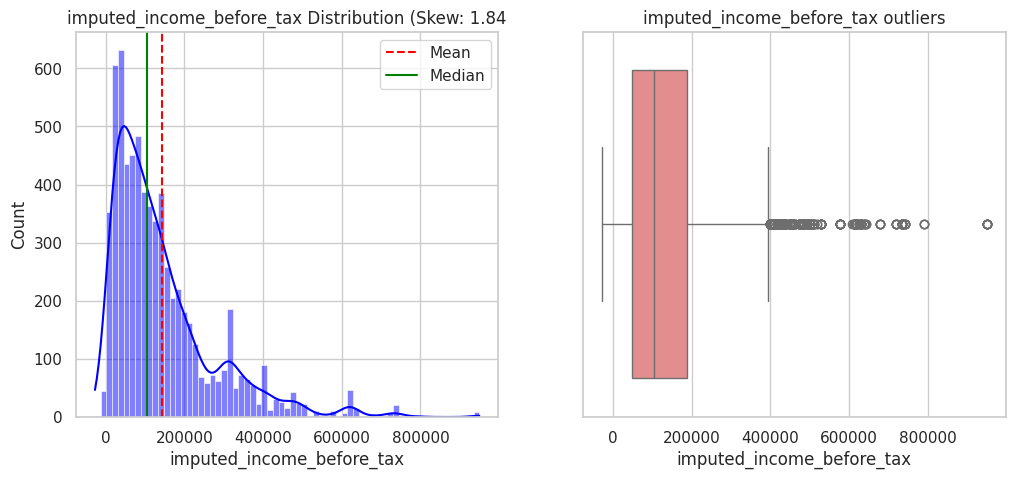

In [7]:
col_target = "imputed_income_before_tax"

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df[col_target],kde=True,color='blue')
plt.axvline(df[col_target].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(df[col_target].median(),color='green',linestyle='-',label='Median')
plt.title(f'{col_target} Distribution (Skew: {df[col_target].skew():.2f}')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x=df[col_target],color='lightcoral')
plt.title(f'{col_target} outliers')
plt.show()
plt.show()

In [38]:
print(df[col].skew())
print(df['product_description'].head())

2.7421147128363126
0    Cable and satellite television services
1    Cable and satellite television services
2    Cable and satellite television services
3    Cable and satellite television services
4    Cable and satellite television services
Name: product_description, dtype: object


2. Categorical variables

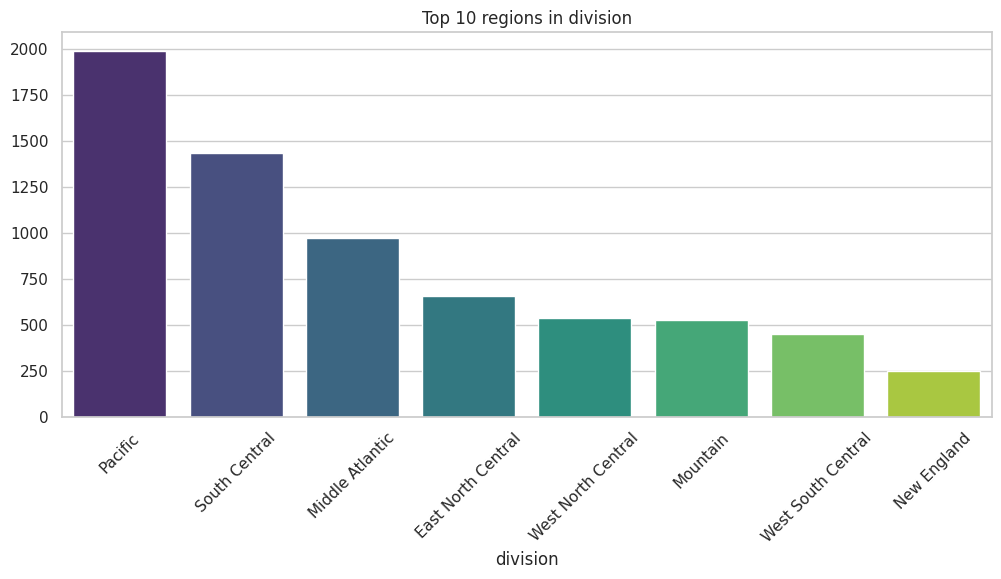

Vital few categories: 6/8 (75.00%)
They cover exactly 85.00% as the target threshold (actual coverage will be >= 85.00%).
division
Pacific               29.16
South Central         50.22
Middle Atlantic       64.47
East North Central    74.11
West North Central    81.96
Mountain              89.72 %
division
Pacific               1989
South Central         1436
Middle Atlantic        972
East North Central     657
West North Central     536
Mountain               529
West South Central     449
New England            252
Name: count, dtype: int64


In [12]:
cat_col = 'division'

counts = df[cat_col].value_counts()
points = df[cat_col].value_counts(normalize=True)
cum_sum = points.cumsum()

plt.figure(figsize=(12,5))
sns.barplot(x=counts.index[:10],y=counts.values[:10],palette='viridis')
plt.title(f'Top 10 regions in {cat_col}')
plt.xticks(rotation=45)
plt.show()
threshold = 0.85
vital_few = cum_sum[cum_sum <= threshold]

# add the first category that crosses the threshold (if it exists)
if len(vital_few) < len(cum_sum):
    vital_few = cum_sum.iloc[:len(vital_few)+1]

portion_pct = (len(vital_few) / len(counts)) * 100

print(f"Vital few categories: {len(vital_few)}/{len(counts)} ({portion_pct:.2f}%)")
print(f"They cover exactly {threshold*100:.2f}% as the target threshold (actual coverage will be >= {threshold*100:.2f}%).")
vital_few_pct = (vital_few * 100).round(2)
print(vital_few_pct.to_string() + " %")
print(counts)



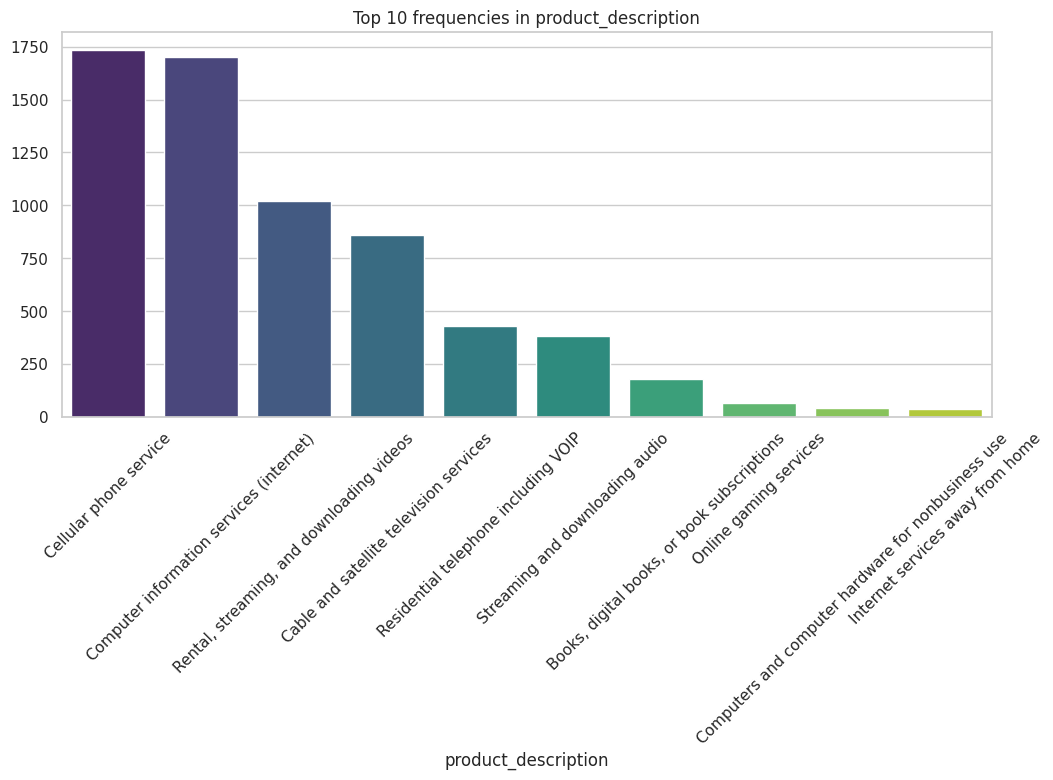

Vital product categories: 5/32 (15.62%)
They cover exactly 85.00% as the target threshold (actual coverage will be >= 85.00%).
product_description
Cellular phone service                       25.41
Computer information services (internet)     50.38
Rental, streaming, and downloading videos    65.35
Cable and satellite television services      77.99
Residential telephone including VOIP         84.27 %
product_description
Cellular phone service                                     1733
Computer information services (internet)                   1703
Rental, streaming, and downloading videos                  1021
Cable and satellite television services                     862
Residential telephone including VOIP                        428
Streaming and downloading audio                             381
Books, digital books, or book subscriptions                 177
Online gaming services                                       68
Computers and computer hardware for nonbusiness use          41


In [14]:
cat_product = 'product_description'

cat_count = df[cat_product].value_counts()
cat_points = df[cat_product].value_counts(normalize=True)
cumulative_pct = cat_points.cumsum()

plt.figure(figsize=(12,5))
sns.barplot(x=cat_count.head(10).index,y=cat_count.head(10).values,palette='viridis')
plt.xticks(rotation=45)
plt.title(f'Top 10 frequencies in {cat_product}')
plt.show()

threshold = 0.85
vital_product = cumulative_pct[cumulative_pct <= threshold]

# add the first category that crosses the threshold (if it exists)
if len(vital_product) < len(cumulative_pct):
    vital_few = cumulative_pct.iloc[:len(vital_product)+1]

product_portion = (len(vital_product) / len(cat_count)) * 100

print(f"Vital product categories: {len(vital_product)}/{len(cat_count)} ({product_portion:.2f}%)")
print(f"They cover exactly {threshold*100:.2f}% as the target threshold (actual coverage will be >= {threshold*100:.2f}%).")
vital_product_pct = (vital_product * 100).round(2)
print(vital_product_pct.to_string() + " %")
print(cat_count)




Step 5: Bivariate analysis
How do variables or columns in our dataset interact ? how are they related ?
1.Numerical vs Numerical(Correlation)

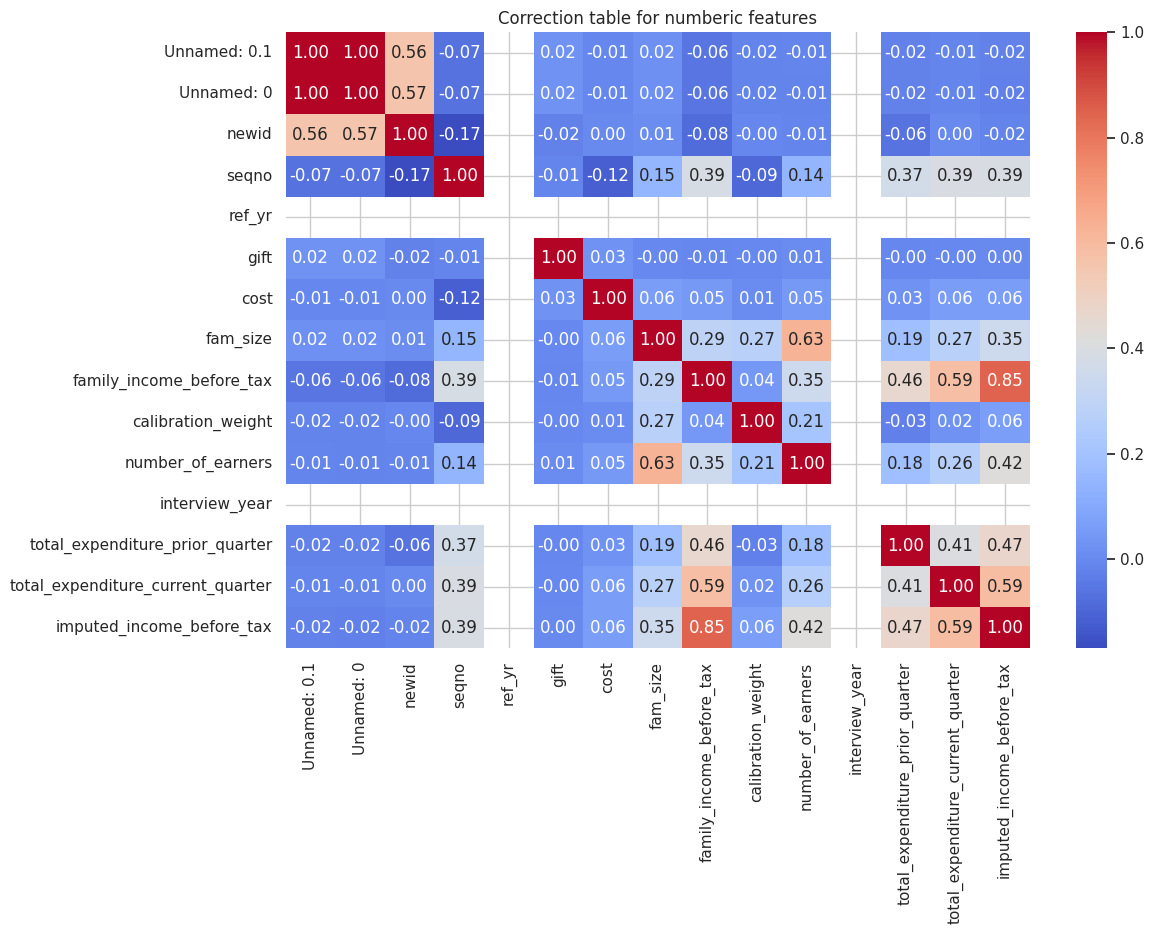

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correction table for numberic features")
plt.show()

2. Categorical vs Numerical

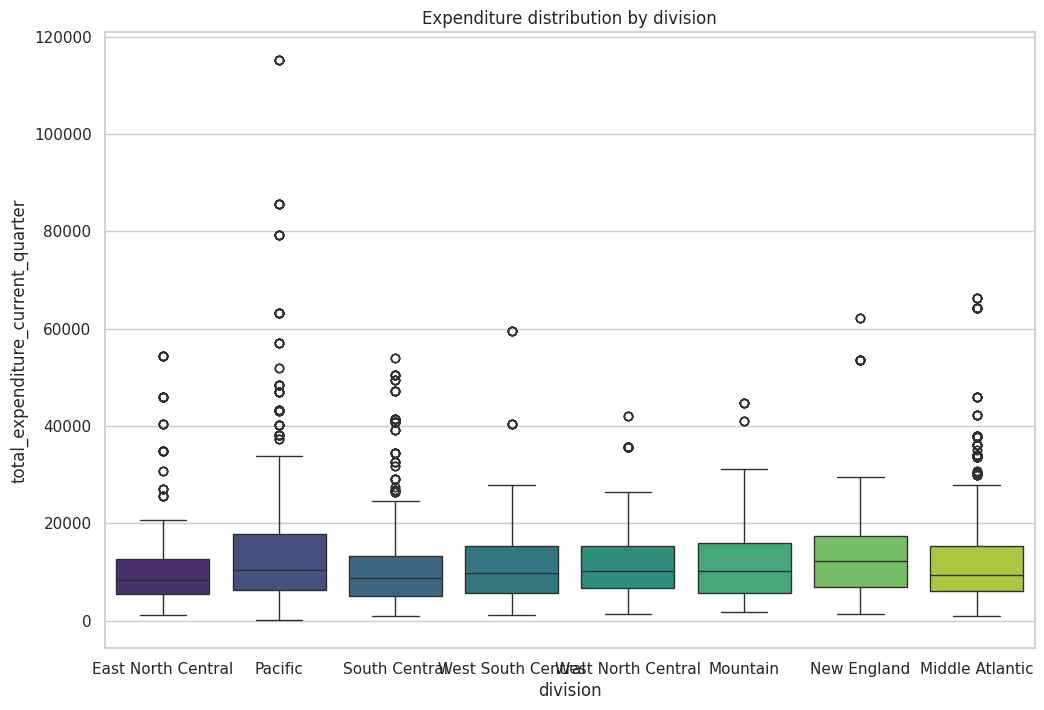

In [44]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x='division',y='total_expenditure_current_quarter',palette='viridis')
plt.title("Expenditure distribution by division")
plt.show()